## 暫態延遲效能分析

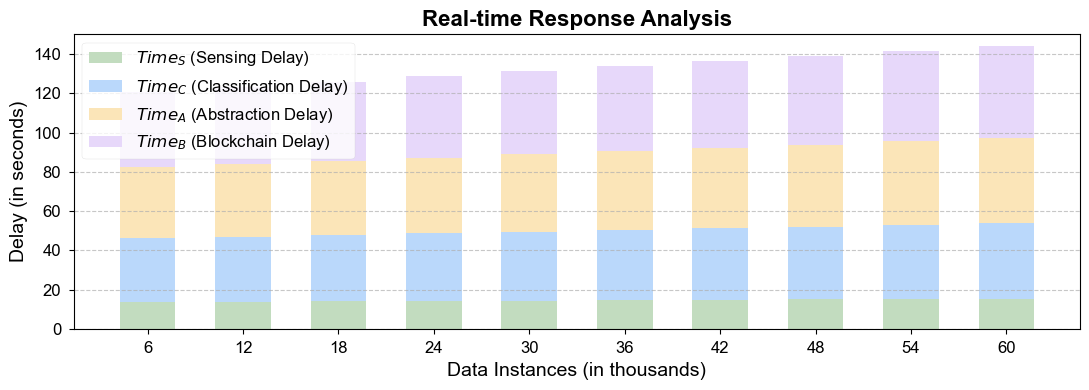

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# --- 圖表整體風格設定 ---
# 設定字體以支援中文顯示（請根據您的作業系統選擇字體，例如 'Microsoft JhengHei' for Windows）
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題
plt.style.use('seaborn-v0_8-paper') # 使用學術論文風格

# --- 數據準備 ---
# 1. 定義X軸：數據實例的數量（單位：千）
data_instances = np.array([6, 12, 18, 24, 30, 36, 42, 48, 54, 60])

# 2. 根據您論文中提供的基礎延遲數據，生成模擬數據
# 假設延遲會隨著數據量增加而呈現小幅度的線性增長
base_time_s = 13.54  # 數據感測時間 (Time_S)
base_time_c = 32.54  # 數據分類延遲 (Time_C)
base_time_a = 36.21  # 時間抽象延遲 (Time_A)
base_time_b = 38.50  # 區塊鏈儲存延遲 (Time_B)

# 生成隨數據實例增加的延遲時間序列
time_s = base_time_s * (1 + 0.015 * (data_instances / data_instances.min() - 1))
time_c = base_time_c * (1 + 0.020 * (data_instances / data_instances.min() - 1))
time_a = base_time_a * (1 + 0.022 * (data_instances / data_instances.min() - 1))
time_b = base_time_b * (1 + 0.025 * (data_instances / data_instances.min() - 1))

# --- 繪製堆疊長條圖 ---
fig, ax = plt.subplots(figsize=(11, 4))

# 定義顏色
colors = ["#c2dcbf",'#bad8fb', '#fbe5b8', '#e7d8fa']

# 繪製各個延遲組件
ax.bar(data_instances, time_s, label='$Time_S$ (Sensing Delay)', width=3.5, color=colors[0])
ax.bar(data_instances, time_c, bottom=time_s, label='$Time_C$ (Classification Delay)', width=3.5, color=colors[1])
ax.bar(data_instances, time_a, bottom=time_s + time_c, label='$Time_A$ (Abstraction Delay)', width=3.5, color=colors[2])
ax.bar(data_instances, time_b, bottom=time_s + time_c + time_a, label='$Time_B$ (Blockchain Delay)', width=3.5, color=colors[3])

# --- 圖表美化與標示 ---
ax.set_xlabel('Data Instances (in thousands)', fontsize=14)
ax.set_ylabel('Delay (in seconds)', fontsize=14)
ax.set_title('Real-time Response Analysis', fontsize=16, weight='bold')

# 設定X軸刻度
ax.set_xticks(data_instances)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# 顯示圖例
ax.legend(fontsize=12)

# 顯示網格線
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, 150) # 可根據需求調整Y軸範圍

# 讓版面更緊湊
plt.tight_layout()

# 儲存圖檔 (建議儲存為高解析度的向量圖格式如 .pdf 或 .svg)
plt.savefig("temporal_delay_efficacy.png", format="png", dpi=600)


# 顯示圖表
plt.show()

## 決策效率比較分析

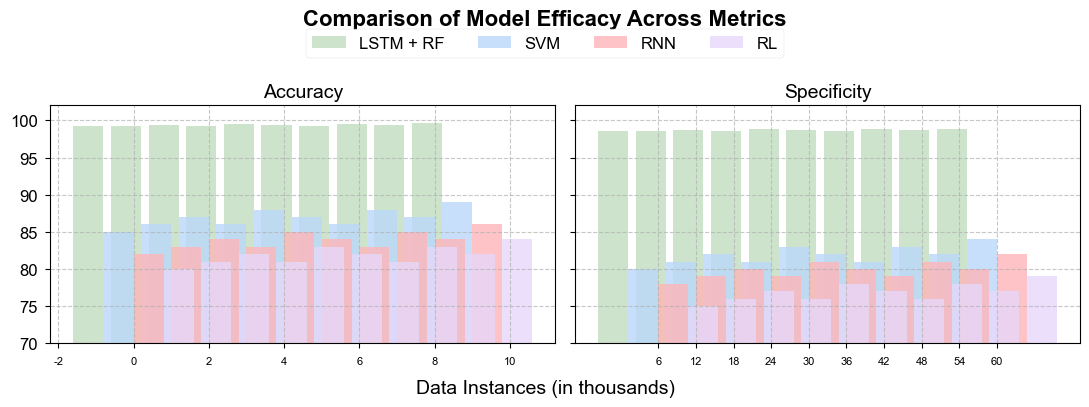

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# --- 圖表整體風格設定 ---
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# --- 數據準備 ---
data_instances = np.array([6, 12, 18, 24, 30, 36, 42, 48, 54, 60])

# 模擬數據（請根據實際數據替換）
lstm_rf_acc = np.array([99.2, 99.3, 99.4, 99.3, 99.5, 99.4, 99.3, 99.5, 99.4, 99.6])
lstm_rf_spec = np.array([98.5, 98.6, 98.7, 98.6, 98.8, 98.7, 98.6, 98.8, 98.7, 98.9])
svm_acc = np.array([85, 86, 87, 86, 88, 87, 86, 88, 87, 89])
svm_spec = np.array([80, 81, 82, 81, 83, 82, 81, 83, 82, 84])
rnn_acc = np.array([82, 83, 84, 83, 85, 84, 83, 85, 84, 86])
rnn_spec = np.array([78, 79, 80, 79, 81, 80, 79, 81, 80, 82])
rl_acc = np.array([80, 81, 82, 81, 83, 82, 81, 83, 82, 84])
rl_spec = np.array([75, 76, 77, 76, 78, 77, 76, 78, 77, 79])

# --- 繪製多面板長條圖 ---
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
bar_width = 0.8
index = np.arange(len(data_instances))

# Accuracy
axs[0].bar(index - 1.5 * bar_width, lstm_rf_acc, bar_width, label='LSTM + RF', color='#C2DCBF', alpha=0.8)
axs[0].bar(index - 0.5 * bar_width, svm_acc, bar_width, label='SVM', color='#BAD8FB', alpha=0.8)
axs[0].bar(index + 0.5 * bar_width, rnn_acc, bar_width, label='RNN', color='#FEB5B8', alpha=0.8)
axs[0].bar(index + 1.5 * bar_width, rl_acc, bar_width, label='RL', color='#E7D8FA', alpha=0.8)
axs[0].set_title('Accuracy', fontsize=14)
axs[0].set_ylim(70, 102)
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].tick_params(axis='y', labelsize=12)

# Specificity
axs[1].bar(index - 1.5 * bar_width, lstm_rf_spec, bar_width, label='LSTM + RF', color='#C2DCBF', alpha=0.8)
axs[1].bar(index - 0.5 * bar_width, svm_spec, bar_width, label='SVM', color='#BAD8FB', alpha=0.8)
axs[1].bar(index + 0.5 * bar_width, rnn_spec, bar_width, label='RNN', color='#FEB5B8', alpha=0.8)
axs[1].bar(index + 1.5 * bar_width, rl_spec, bar_width, label='RL', color='#E7D8FA', alpha=0.8)
axs[1].set_title('Specificity', fontsize=14)
axs[1].set_ylim(70, 102)
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].tick_params(axis='y', labelsize=12)

# --- 圖表美化 ---
fig.text(0.5, 0.02, 'Data Instances (in thousands)', ha='center', fontsize=14)  # 降低X軸標籤位置
# fig.text(0.04, 0.5, 'Performance (%)', va='center', rotation='vertical', fontsize=14)
fig.suptitle('Comparison of Model Efficacy Across Metrics', fontsize=16, weight='bold')

# 顯示圖例
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=4, fontsize=12)

plt.xticks(index, data_instances)
plt.tight_layout(rect=[0, 0.05, 1, 0.92])  # 調整rect參數，留出底部空間
plt.savefig("model_efficacy_bar_top.png", format="png", dpi=600, bbox_inches='tight')
plt.show()

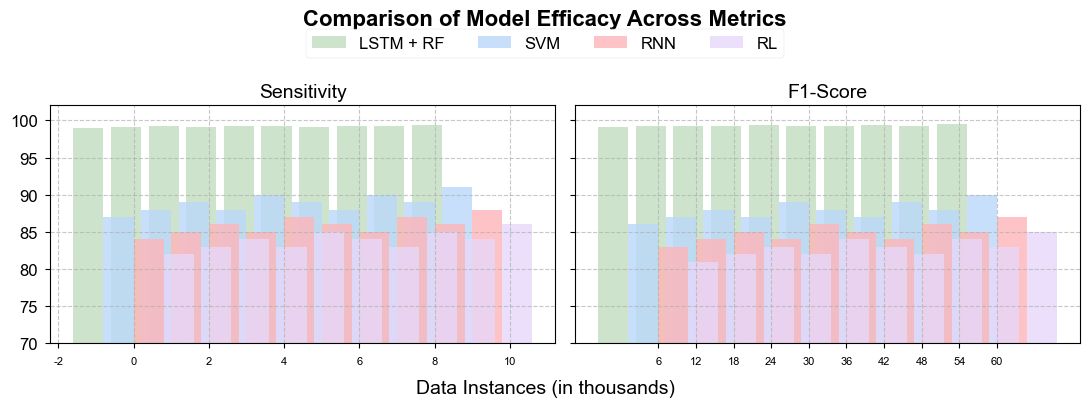

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# --- 圖表整體風格設定 ---
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# --- 數據準備 ---
data_instances = np.array([6, 12, 18, 24, 30, 36, 42, 48, 54, 60])

# 模擬數據（請根據實際數據替換）
lstm_rf_sens = np.array([99.0, 99.1, 99.2, 99.1, 99.3, 99.2, 99.1, 99.3, 99.2, 99.4])
lstm_rf_f1 = np.array([99.1, 99.2, 99.3, 99.2, 99.4, 99.3, 99.2, 99.4, 99.3, 99.5])
svm_sens = np.array([87, 88, 89, 88, 90, 89, 88, 90, 89, 91])
svm_f1 = np.array([86, 87, 88, 87, 89, 88, 87, 89, 88, 90])
rnn_sens = np.array([84, 85, 86, 85, 87, 86, 85, 87, 86, 88])
rnn_f1 = np.array([83, 84, 85, 84, 86, 85, 84, 86, 85, 87])
rl_sens = np.array([82, 83, 84, 83, 85, 84, 83, 85, 84, 86])
rl_f1 = np.array([81, 82, 83, 82, 84, 83, 82, 84, 83, 85])

# --- 繪製多面板長條圖 ---
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
bar_width = 0.8
index = np.arange(len(data_instances))

# Sensitivity
axs[0].bar(index - 1.5 * bar_width, lstm_rf_sens, bar_width, label='LSTM + RF', color='#C2DCBF', alpha=0.8)
axs[0].bar(index - 0.5 * bar_width, svm_sens, bar_width, label='SVM', color='#BAD8FB', alpha=0.8)
axs[0].bar(index + 0.5 * bar_width, rnn_sens, bar_width, label='RNN', color='#FEB5B8', alpha=0.8)
axs[0].bar(index + 1.5 * bar_width, rl_sens, bar_width, label='RL', color='#E7D8FA', alpha=0.8)
axs[0].set_title('Sensitivity', fontsize=14)
axs[0].set_ylim(70, 102)
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].tick_params(axis='y', labelsize=12)

# F1-Score
axs[1].bar(index - 1.5 * bar_width, lstm_rf_f1, bar_width, label='LSTM + RF', color='#C2DCBF', alpha=0.8)
axs[1].bar(index - 0.5 * bar_width, svm_f1, bar_width, label='SVM', color='#BAD8FB', alpha=0.8)
axs[1].bar(index + 0.5 * bar_width, rnn_f1, bar_width, label='RNN', color='#FEB5B8', alpha=0.8)
axs[1].bar(index + 1.5 * bar_width, rl_f1, bar_width, label='RL', color='#E7D8FA', alpha=0.8)
axs[1].set_title('F1-Score', fontsize=14)
axs[1].set_ylim(70, 102)
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].tick_params(axis='y', labelsize=12)

# --- 圖表美化 ---
fig.text(0.5, 0.02, 'Data Instances (in thousands)', ha='center', fontsize=14)  # 降低X軸標籤位置
# fig.text(0.04, 0.5, 'Performance (%)', va='center', rotation='vertical', fontsize=14)
fig.suptitle('Comparison of Model Efficacy Across Metrics', fontsize=16, weight='bold')

# 顯示圖例
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=4, fontsize=12)

plt.xticks(index, data_instances)
plt.tight_layout(rect=[0, 0.05, 1, 0.92])  # 調整rect參數，留出底部空間
plt.savefig("model_efficacy_bar_bottom.png", format="png", dpi=600, bbox_inches='tight')
plt.show()

## 穩定性分析-雷達圖

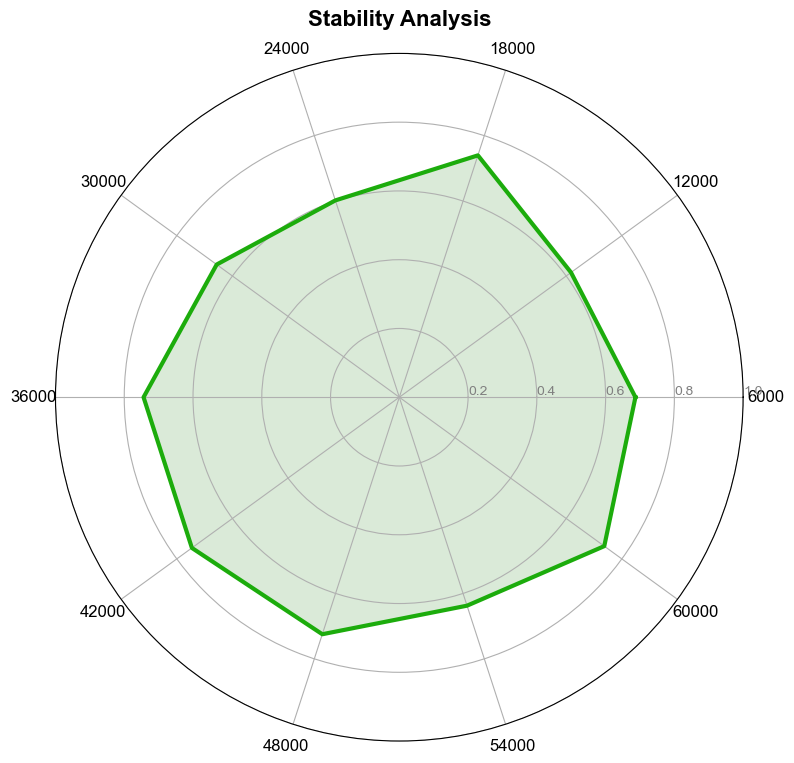

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# --- 圖表整體風格設定 ---
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# --- 數據準備 ---
categories = [str(i * 6000) for i in range(1, 11)] # 軸標籤
num_vars = len(categories)
# 生成10個在指定範圍內的穩定性測量值
stability_values = np.random.uniform(0.59, 0.75, num_vars)
# 為了讓雷達圖閉合，需要將第一個點的值附加到數組末尾
stability_values = np.concatenate((stability_values, [stability_values[0]]))

# 計算每個軸的角度
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# --- 繪製圖表 ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

ax.set_title('Stability Analysis', fontsize=16, weight='bold', pad=20)

# 繪製數據線和填充區域，使用新的色系
ax.plot(angles, stability_values, color="#1CAC0C", linewidth=3, linestyle='solid')
ax.fill(angles, stability_values, color='#C2DCBF', alpha=0.6)

# 設定雷達圖的標籤和外觀
ax.set_yticklabels([]) # 隱藏預設的半徑標籤
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)

# 設置半徑網格線和標籤
ax.set_rlabel_position(0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
ax.set_ylim(0, 1.0)

# --- 儲存與顯示圖表 ---
plt.tight_layout()
# plt.savefig("stability_analysis_radar.pdf", format="pdf", dpi=300)
plt.savefig("stability_analysis_radar.png", format="png", dpi=300)
plt.show()

## 可靠性分析 (Reliability Analysis) - 散點圖

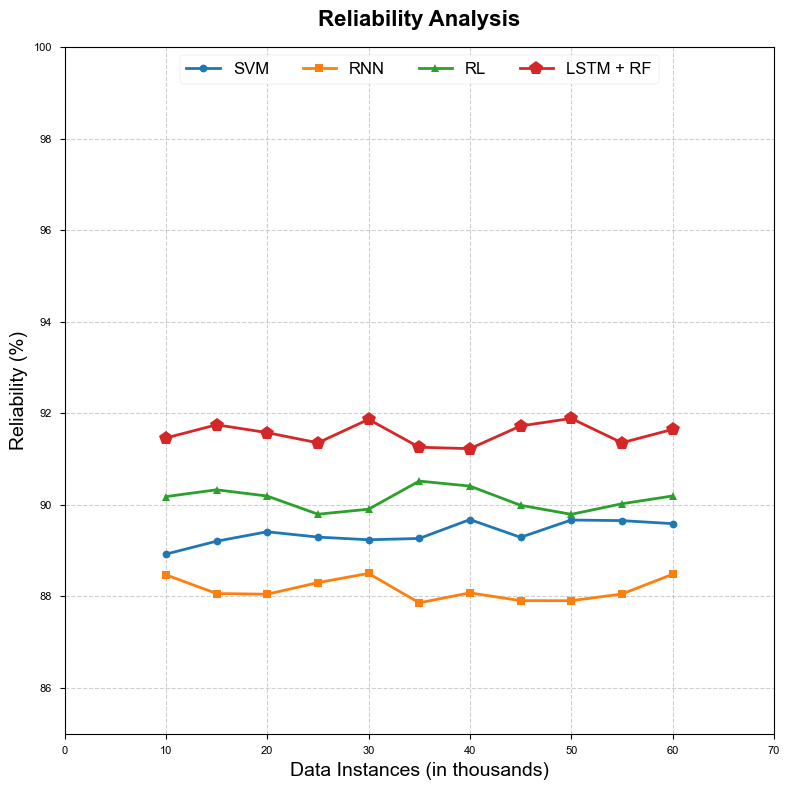

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# --- 圖表整體風格設定 ---
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# --- 數據準備 ---
data_instances = np.arange(10, 61, 5) # X軸: 10k, 15k, ..., 60k
def generate_reliability_data(base_value, size, noise_level=0.4):
    return base_value + np.random.uniform(-noise_level, noise_level, size)

rel_svm = generate_reliability_data(89.32, len(data_instances))
rel_rnn = generate_reliability_data(88.21, len(data_instances))
rel_rl = generate_reliability_data(90.17, len(data_instances))
rel_proposed = generate_reliability_data(91.58, len(data_instances))

# --- 繪製圖表 ---
fig, ax = plt.subplots(figsize=(8, 8))

# 繪製折線圖
ax.plot(data_instances, rel_svm, label='SVM', linewidth=2, marker='o')
ax.plot(data_instances, rel_rnn, label='RNN', linewidth=2, marker='s')
ax.plot(data_instances, rel_rl, label='RL', linewidth=2, marker='^')
ax.plot(data_instances, rel_proposed, label='LSTM + RF', linewidth=2, marker='p', markersize=10) # 突顯Proposed

# 設定圖表標籤、標題和圖例
ax.set_title('Reliability Analysis', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('Data Instances (in thousands)', fontsize=14)
ax.set_ylabel('Reliability (%)', fontsize=14)
ax.legend(loc='upper center', ncol=4, fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# 設定座標軸範圍
ax.set_xlim(0, 70)
ax.set_ylim(85, 100)

# --- 儲存與顯示圖表 ---
plt.tight_layout()
plt.savefig("reliability_analysis_line.pdf", format="pdf", dpi=300)
plt.savefig("reliability_analysis_line.png", format="png", dpi=300)
plt.show()